<a href="https://colab.research.google.com/github/rb7488/DS_ML-Learning/blob/main/Feature_Engineering_DS_udemy5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#Feature Engineering


In [ ]:
#Feature Engineering


Examples


In [ ]:
import seaborn as sns
df=sns.load_dataset('titanic')

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
#Delete the row or data  points to handle the missing values
df.shape

(891, 15)

In [ ]:
df.dropna().shape # we cannot do due huge data loss

(182, 15)

In [ ]:
#column wise deletion
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


Imputation Missing values

1.Mean Value imputation


In [ ]:
df['age'].skew()

np.float64(0.38910778230082704)

<Axes: xlabel='age', ylabel='Count'>

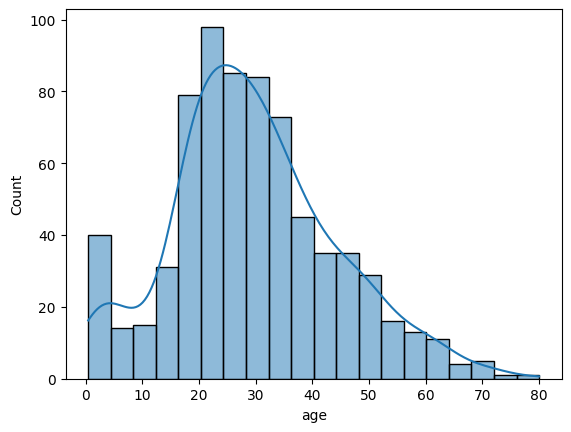

In [ ]:
sns.histplot(df['age'], kde=True ) #looks like normal distribn

In [ ]:
df['age'].mean()

np.float64(29.69911764705882)

In [ ]:
df['age_mean']=df['age'].fillna(df['age'].mean())

In [ ]:
df[['age_mean','age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [ ]:
#mean imputation works well when we have normally distributed data

2.Median Imputation: used when dataset have outliers

In [ ]:
df['age'].median()

28.0

In [ ]:
df['age_median']=df['age'].fillna(df['age'].median())

In [ ]:
df[['age_median','age']]

,age_median,age
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,28.0,NaN
889,26.0,26.0


3.Mode imputation: for categorical column data

In [ ]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [ ]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
mode_value=df[df['embarked'].notna()]['embarked'].mode()[0]

In [ ]:
df['embarked_mode']=df['embarked'].fillna(mode_value)

In [ ]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [ ]:
df['embarked_mode'].isnull().sum()

np.int64(0)


**Handling Imbalance Dataset**

In [3]:
import pandas as pd
import numpy as np
#set the random seed for reproductibility
np.random.seed(123)
#create a dataframe with two classes
n_samples=1000
class_0_ratio=0.9
n_class_0=int(n_samples * class_0_ratio)
n_class_1=n_samples - n_class_0


In [4]:
n_class_0,n_class_1


(900, 100)

In [5]:
#creating my  data frame with imbalanced dataset
class_0=pd.DataFrame({
   'feature1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})

class_1 =pd.DataFrame({
    'feature1':np.random.normal(loc=2,scale=1,size=n_class_1),
    'feature2':np.random.normal(loc=2,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})



In [6]:
df = pd.concat([class_0,class_1]).reset_index(drop=True)

In [7]:
df.head()

,feature1,feature2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [8]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [9]:
#upsampling
df_miniority=df[df['target']==1]
df_majority=df[df['target']==0]

In [10]:
from sklearn.utils import resample
df_miniority_upsample = resample(df_miniority,replace=True, #smple with replacement
            n_samples=len(df_majority),
         random_state=42
        )

In [11]:
df_miniority_upsample.shape

(900, 3)

In [12]:
df_miniority_upsample.head()

,feature1,feature2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [13]:
df_upsampled=pd.concat([df_majority,df_miniority_upsample])

In [14]:
df_upsampled['target'].value_counts()

,count
target,
0,900
1,900


In [15]:
#Downsampling
df_miniority=df[df['target']==1]
df_majority=df[df['target']==0]

In [16]:
from sklearn.utils import resample
df_majourity_downsample = resample(df_miniority,replace=False, #smple with replacement
            n_samples=len(df_miniority),
         random_state=42
        )

In [20]:
df_majourity_downsample.shape

(100, 3)

In [21]:
df_downsampled=pd.concat([df_miniority,df_majourity_downsample])

In [22]:
df_downsampled['target'].value_counts()

,count
target,
1,200


In [28]:
#Smote techniques
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000, n_redundant=0, n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=12)


In [32]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()
final_df['target'].value_counts()

,count
target,
0,900
1,100


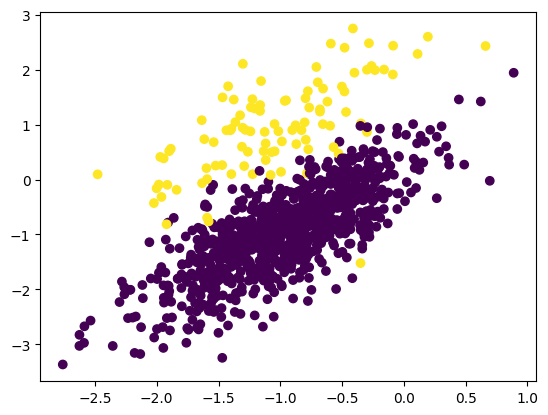

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(final_df[ 'f1'],final_df['f2'],c=final_df['target'])


applying SMOTE

In [37]:
!pip install imblearn

In [42]:
from imblearn.over_sampling import SMOTE


In [43]:
oversample=SMOTE()
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [44]:
X.shape

(1800, 2)

In [46]:
len(y[y==0])

900

In [49]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)


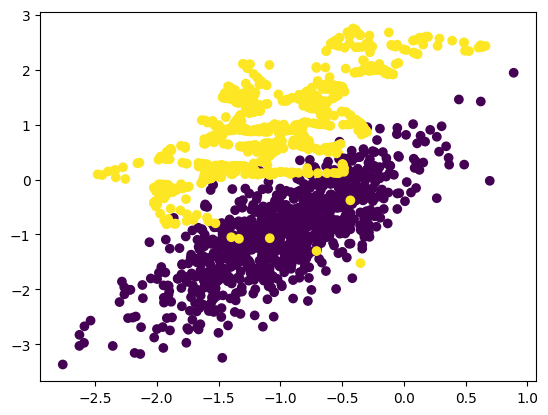

In [50]:
plt.scatter(oversample_df[ 'f1'],oversample_df['f2'],c=oversample_df['target'])
